:meth:`SeqMutPlot.epistasis` maps the pairwise non-additivity of mutations — built from a :meth:`SeqMut.combine` table holding the single mutations and their pairwise combinations. Off-diagonal cells show ``ΔP(i+j) - (ΔP(i) + ΔP(j))``: red = synergy, blue = antagonism.

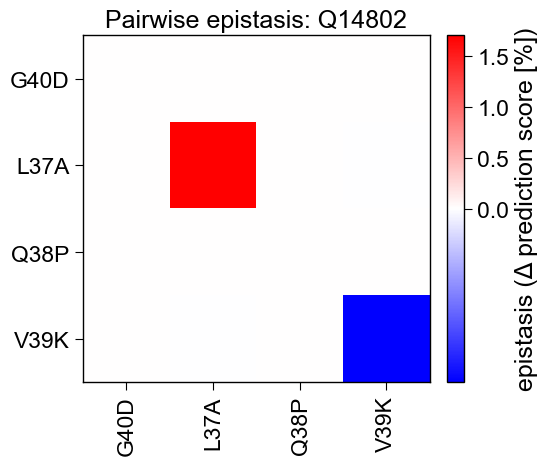

In [1]:
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import aaanalysis as aa
aa.options["verbose"] = False

# Data, CPP features, and a fitted TreeModel that scores each sequence
df_seq = aa.load_dataset(name="DOM_GSEC", n=10)
labels = df_seq["label"].to_list()
sf = aa.SequenceFeature()
df_parts = sf.get_df_parts(df_seq=df_seq)
split_kws = sf.get_split_kws()
df_scales = aa.load_scales()
cpp = aa.CPP(df_parts=df_parts, split_kws=split_kws, df_scales=df_scales, verbose=False)
df_feat = cpp.run(labels=labels, n_filter=25)
X = sf.feature_matrix(features=list(df_feat["feature"]), df_parts=df_parts, df_scales=df_scales)
tm = aa.TreeModel().fit(X, labels=labels)
entry = df_seq["entry"].iloc[0]
ts = int(df_seq.set_index("entry").loc[entry, "tmd_start"])

muts = [(ts, "A"), (ts + 1, "P"), (ts + 2, "K"), (ts + 3, "D")]
rows = [(entry, f"m{k}", p, a) for k, (p, a) in enumerate(muts)]
for (i, (p1, a1)), (j, (p2, a2)) in itertools.combinations(enumerate(muts), 2):
    rows += [(entry, f"m{i}_m{j}", p1, a1), (entry, f"m{i}_m{j}", p2, a2)]
variants = pd.DataFrame(rows, columns=["entry", "variant", "pos", "to_aa"])
df_variant = aa.SeqMut(model=tm).combine(df_seq=df_seq, variants=variants, df_feat=df_feat)
aa.plot_settings()
aa.SeqMutPlot().epistasis(df_variant=df_variant, entry=entry, cmap="bwr", figsize=(6, 5))
plt.tight_layout()
plt.show()